# Publication Figures — Contested Shot Analysis
All publication-quality visualizations for the Action-3D model.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

FIG_DIR = Path('../data/outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linewidth':   0.6,
    'figure.dpi':       150,
})
print('Setup complete.')

Setup complete.


## Figure 1 — Forest Plot: Pose Feature Odds Ratios with 95% Bootstrap CIs

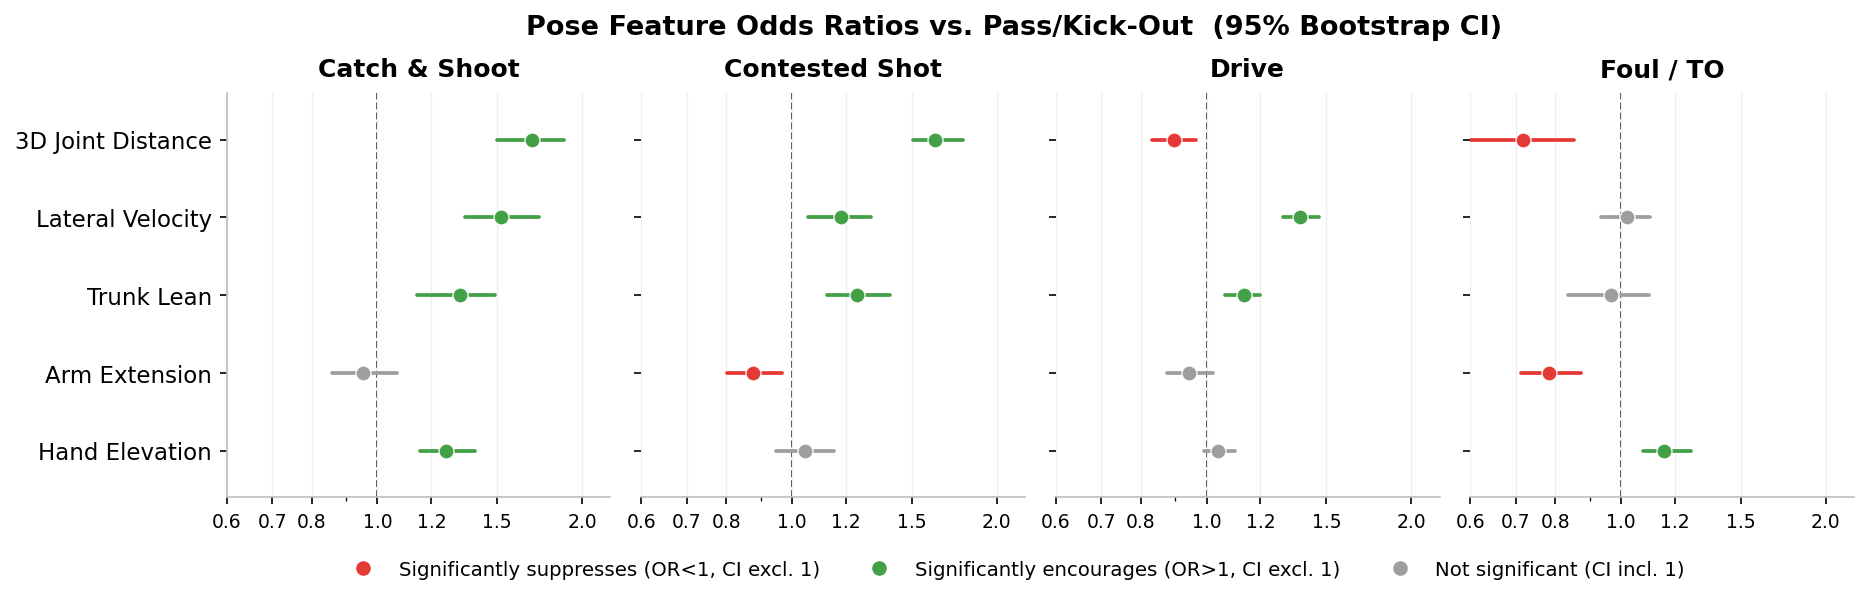

Saved → ../data/outputs/figures/forest_plot_or_ci.png


In [12]:
# ── Load data ─────────────────────────────────────────────────────────────────
ci_df = pd.read_csv('../data/outputs/action_model_bootstrap_or_ci.csv')

POSE_FEATURES = [
    'def_hand_elev_above_ball_in',
    'arm_extension_ratio',
    'trunk_lean_deg',
    'lateral_velocity_ft_s',
    'min_def_joint_dist_ft',
]
FEAT_LABELS = {
    'def_hand_elev_above_ball_in': 'Hand Elevation',
    'arm_extension_ratio':         'Arm Extension',
    'trunk_lean_deg':              'Trunk Lean',
    'lateral_velocity_ft_s':       'Lateral Velocity',
    'min_def_joint_dist_ft':       '3D Joint Distance',
}
CLASS_TITLES = {
    'catch_and_shoot': 'Catch & Shoot',
    'contested_shot':  'Contested Shot',
    'drive':           'Drive',
    'foul_turnover':   'Foul / TO',
}
CLASS_ORDER = ['catch_and_shoot', 'contested_shot', 'drive', 'foul_turnover']

# bottom-to-top display order on y-axis
FEAT_ORDER   = POSE_FEATURES                    # index 0 = bottom
Y_POSITIONS  = {f: i for i, f in enumerate(FEAT_ORDER)}
Y_LABELS     = [FEAT_LABELS[f] for f in FEAT_ORDER]

df = ci_df[ci_df['feature'].isin(POSE_FEATURES)].copy()

# ── Color coding ──────────────────────────────────────────────────────────────
def dot_color(row):
    ci_excludes_1 = not (row.ci_lower <= 1.0 <= row.ci_upper)
    if not ci_excludes_1:
        return '#9e9e9e'           # gray — n.s.
    return '#43a047' if row.or_point > 1 else '#e53935'  # red / green

df['color'] = df.apply(dot_color, axis=1)

# ── Build figure ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 4,
    figsize=(14, 3.5),
    sharey=True,
    gridspec_kw={'wspace': 0.08},
)
fig.patch.set_facecolor('white')

X_MIN, X_MAX = 0.6, 2.2

for ax, cls in zip(axes, CLASS_ORDER):
    sub = df[df['class_label'] == cls].set_index('feature')

    # reference line
    ax.axvline(1.0, color='#424242', linewidth=0.9, linestyle='--', zorder=1)

    for feat in FEAT_ORDER:
        if feat not in sub.index:
            continue
        row  = sub.loc[feat]
        ypos = Y_POSITIONS[feat]
        col  = row['color']

        # CI bar
        ax.plot(
            [row.ci_lower, row.ci_upper], [ypos, ypos],
            color=col, linewidth=1.8, solid_capstyle='round', zorder=2,
        )
        # center dot
        ax.scatter(
            row.or_point, ypos,
            color=col, s=52, zorder=3, edgecolors='white', linewidths=0.6,
        )

    ax.set_xscale('log')
    ax.set_xlim(X_MIN, X_MAX)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(
        lambda x, _: f'{x:.1f}' if x != 1 else '1.0'
    ))
    ax.set_xticks([0.6, 0.7, 0.8, 1.0, 1.2, 1.5, 2.0])
    ax.set_title(CLASS_TITLES[cls], fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('', fontsize=10)
    ax.tick_params(axis='x', labelsize=9)
    ax.set_facecolor('white')
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#bdbdbd')
    ax.grid(axis='x', color='#eeeeee', linewidth=0.6, zorder=0)
    ax.grid(axis='y', visible=False)

# Y-axis labels on leftmost panel only (sharey handles ticks)
axes[0].set_yticks(range(len(FEAT_ORDER)))
axes[0].set_yticklabels(Y_LABELS, fontsize=11)
axes[0].set_ylim(-0.6, len(FEAT_ORDER) - 0.4)
axes[0].spines['left'].set_visible(True)
axes[0].spines['left'].set_color('#bdbdbd')

# Overall title
fig.suptitle(
    'Pose Feature Odds Ratios vs. Pass/Kick-Out  (95% Bootstrap CI)',
    fontsize=13, fontweight='bold', y=1.03,
)

# Legend / caption
from matplotlib.lines import Line2D #43a047 #e53935
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e53935',
           markersize=8, label='Significantly suppresses (OR<1, CI excl. 1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#43a047',
           markersize=8, label='Significantly encourages (OR>1, CI excl. 1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#9e9e9e',
           markersize=8, label='Not significant (CI incl. 1)'),
]
fig.legend(
    handles=legend_elements,
    loc='lower center', ncol=3,
    fontsize=9.5, frameon=False,
    bbox_to_anchor=(0.5, -0.08),
)

out = FIG_DIR / 'forest_plot_or_ci.png'
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out}')

## Figure 2 — Shot Rate vs. 3D Defender Joint Distance

Combined: 6905 touches
Distance percentiles — p10=4.4 ft  p50=9.6 ft  p90=17.9 ft
Shot rate at p10 (4.4 ft): 5.8%
Shot rate at p50 (9.6 ft): 9.0%
Shot rate at p90 (17.9 ft): 17.5%
Bootstrap done. Band width at p50 (9.6 ft): 1.7%


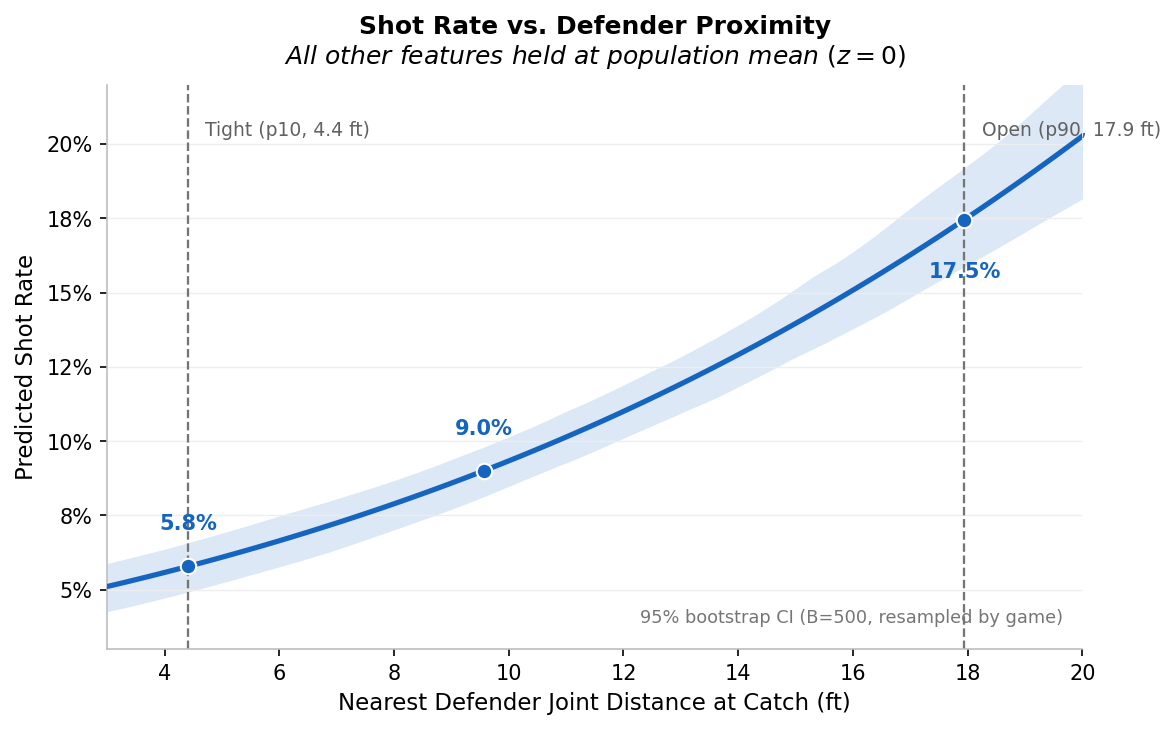

Saved → ../data/outputs/figures/shot_rate_gradient.png


In [9]:
import warnings; warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ── Constants ─────────────────────────────────────────────────────────────────
F2D_CTX = ['n_open_3pt_threats', 'min_kickout_defender_gap_ft',
            'release_shot_clock', 'game_clock_seconds']
POSE    = ['def_hand_elev_above_ball_in', 'arm_extension_ratio', 'trunk_lean_deg',
           'lateral_velocity_ft_s', 'min_def_joint_dist_ft']
F3D     = F2D_CTX + POSE
SHOT_CLASSES = ('catch_and_shoot', 'contested_shot')
DIST_COL     = 'min_def_joint_dist_ft'
DIST_IDX     = F3D.index(DIST_COL)

B   = 500
RNG = np.random.default_rng(42)

# ── 1. Load & clean data ──────────────────────────────────────────────────────
def _load(path):
    df = pd.read_csv(path)
    for c in F3D:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna(subset=['action']).reset_index(drop=True)
    for c in F3D:
        df[c] = df[c].fillna(df[c].mean())
    return df

combined = _load('../data/intermediate/touch_events_combined.csv')
print(f'Combined: {len(combined)} touches')

# ── 2. Compute p10 / p50 / p90 (consistent with Figure 3 and results table) ──
p10 = float(np.percentile(combined[DIST_COL], 10))
p50 = float(np.percentile(combined[DIST_COL], 50))
p90 = float(np.percentile(combined[DIST_COL], 90))
ANN_POINTS = [p10, p50, p90]
print(f'Distance percentiles — p10={p10:.1f} ft  p50={p50:.1f} ft  p90={p90:.1f} ft')

# ── 3. Fit full model ─────────────────────────────────────────────────────────
sc_full = StandardScaler().fit(combined[F3D])
X_all   = sc_full.transform(combined[F3D])
y_all   = combined['action'].values
m_full  = LogisticRegression(solver='lbfgs', C=1.0, max_iter=800).fit(X_all, y_all)
classes  = list(m_full.classes_)
shot_idx = [classes.index(c) for c in SHOT_CLASSES if c in classes]

# ── 4. Prediction grid: hold all features at population mean (z=0), vary dist ─
pop_means = combined[F3D].mean().values
dist_grid = np.linspace(3, 20, 100)

def predict_shot_rate(model, sc, base_row, dist_values):
    grid = np.tile(base_row, (len(dist_values), 1))
    grid[:, DIST_IDX] = dist_values
    probs = model.predict_proba(sc.transform(grid))
    return probs[:, shot_idx].sum(axis=1)

sr_main = predict_shot_rate(m_full, sc_full, pop_means, dist_grid)
print(f'Shot rate at p10 ({p10:.1f} ft): {np.interp(p10, dist_grid, sr_main):.1%}')
print(f'Shot rate at p50 ({p50:.1f} ft): {np.interp(p50, dist_grid, sr_main):.1%}')
print(f'Shot rate at p90 ({p90:.1f} ft): {np.interp(p90, dist_grid, sr_main):.1%}')

# ── 5. Bootstrap CI (resample by game, hold baseline at bootstrap pop mean) ───
game_ids     = combined['game_file'].values
unique_games = combined['game_file'].unique()
boot_curves  = np.zeros((B, len(dist_grid)))

for b in range(B):
    sampled_games = RNG.choice(unique_games, size=len(unique_games), replace=True)
    idx  = np.concatenate([np.where(game_ids == g)[0] for g in sampled_games])
    sub  = combined.iloc[idx]
    sc_b = StandardScaler().fit(sub[F3D])
    base_b = sub[F3D].mean().values
    m_b  = LogisticRegression(solver='lbfgs', C=1.0, max_iter=800).fit(
               sc_b.transform(sub[F3D]), sub['action'].values)
    cls_b  = list(m_b.classes_)
    sidx_b = [cls_b.index(c) for c in SHOT_CLASSES if c in cls_b]
    grid_b = np.tile(base_b, (len(dist_grid), 1))
    grid_b[:, DIST_IDX] = dist_grid
    probs_b = m_b.predict_proba(sc_b.transform(grid_b))
    boot_curves[b] = probs_b[:, sidx_b].sum(axis=1)

ci_lo = np.percentile(boot_curves, 2.5,  axis=0)
ci_hi = np.percentile(boot_curves, 97.5, axis=0)
bw = np.interp(p50, dist_grid, ci_hi) - np.interp(p50, dist_grid, ci_lo)
print(f'Bootstrap done. Band width at p50 ({p50:.1f} ft): {bw:.1%}')

# ── 6. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.fill_between(dist_grid, ci_lo * 100, ci_hi * 100,
                color='#1565C0', alpha=0.15, linewidth=0, zorder=1)
ax.plot(dist_grid, sr_main * 100,
        color='#1565C0', linewidth=2.5, zorder=3)

for x_ref, label in [(p10, f'Tight (p10, {p10:.1f} ft)'), (p90, f'Open (p90, {p90:.1f} ft)')]:
    ax.axvline(x_ref, color='#757575', linewidth=1.1, linestyle='--', zorder=2)
    ax.text(x_ref + 0.3, 20.8, label, color='#616161', fontsize=9, va='top')

for x_ann in ANN_POINTS:
    y_ann = float(np.interp(x_ann, dist_grid, sr_main)) * 100
    ax.scatter(x_ann, y_ann, color='#1565C0', s=55, zorder=4,
               edgecolors='white', linewidths=1.0)
    offset_y = 1.1 if y_ann < 15 else -1.4
    ax.annotate(
        f'{y_ann:.1f}%',
        xy=(x_ann, y_ann),
        xytext=(x_ann, y_ann + offset_y),
        ha='center', va=('bottom' if offset_y > 0 else 'top'),
        fontsize=10, fontweight='bold', color='#1565C0',
    )

ax.set_xlim(3, 20)
ax.set_ylim(3, 22)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.set_xlabel('Nearest Defender Joint Distance at Catch (ft)', fontsize=11)
ax.set_ylabel('Predicted Shot Rate', fontsize=11)
ax.set_title(
    'Shot Rate vs. Defender Proximity\n'
    '$\\it{All\\ other\\ features\\ held\\ at\\ population\\ mean\\ (z=0)}$',
    fontsize=12, fontweight='bold', pad=10,
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdbdbd')
ax.spines['bottom'].set_color('#bdbdbd')
ax.grid(axis='y', color='#eeeeee', linewidth=0.7, zorder=0)
ax.grid(axis='x', visible=False)
ax.tick_params(labelsize=10)
ax.text(0.98, 0.04,
        '95% bootstrap CI (B=500, resampled by game)',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8.5, color='#757575')

plt.tight_layout()
out = FIG_DIR / 'shot_rate_gradient.png'
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out}')


## Figure 3 — Action Distribution by Closeout Tightness

Distance percentiles — p10=4.4 ft  p50=9.6 ft  p90=17.9 ft
  Tight   (4.4 ft): shot_rate=5.8%  pass_kickout=55.7%  drive=25.9%  foul_turnover=12.6%  contested_shot=4.4%  catch_and_shoot=1.4%
  Medium  (9.6 ft): shot_rate=9.0%  pass_kickout=57.1%  drive=24.2%  foul_turnover=9.7%  contested_shot=6.8%  catch_and_shoot=2.2%
  Open    (17.9 ft): shot_rate=17.5%  pass_kickout=56.0%  drive=20.5%  foul_turnover=6.0%  contested_shot=13.1%  catch_and_shoot=4.4%


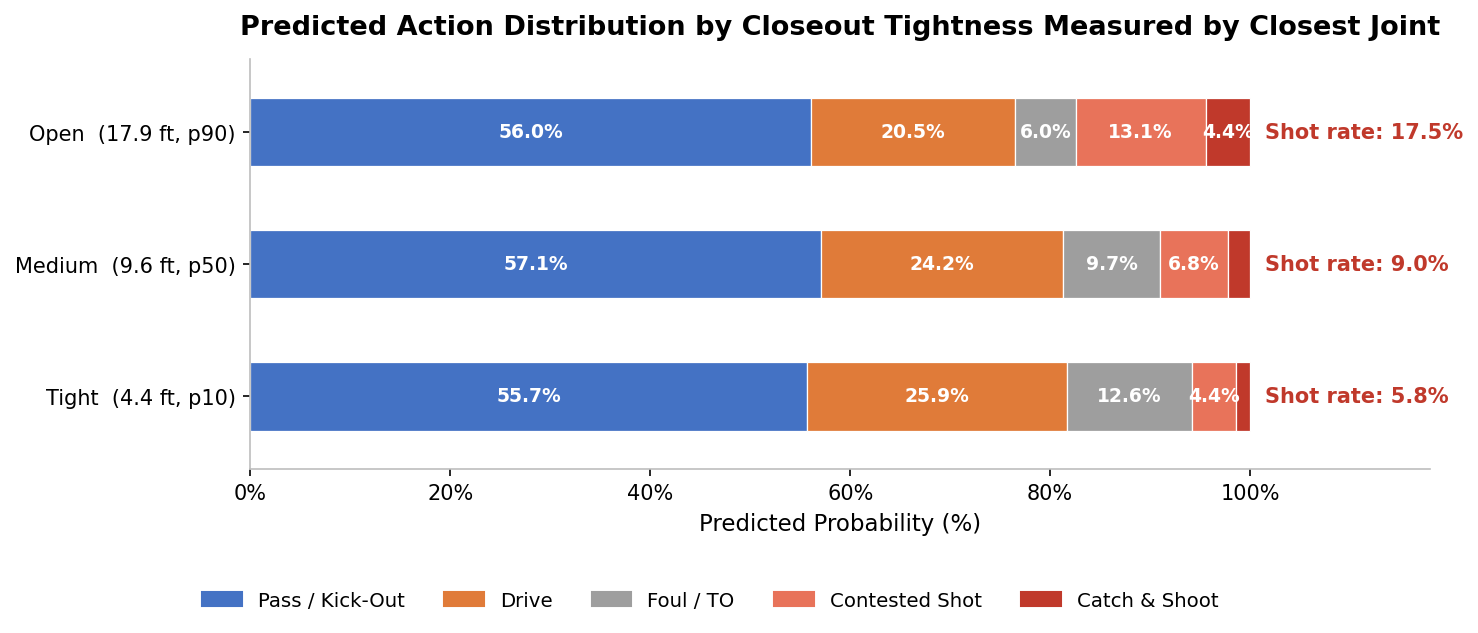

Saved → ../data/outputs/figures/action_distribution_shift.png


In [10]:
import warnings; warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ── Constants ─────────────────────────────────────────────────────────────────
F2D_CTX = ['n_open_3pt_threats', 'min_kickout_defender_gap_ft',
            'release_shot_clock', 'game_clock_seconds']
POSE    = ['def_hand_elev_above_ball_in', 'arm_extension_ratio', 'trunk_lean_deg',
           'lateral_velocity_ft_s', 'min_def_joint_dist_ft']
F3D      = F2D_CTX + POSE
DIST_COL = 'min_def_joint_dist_ft'
DIST_IDX = F3D.index(DIST_COL)

SEG_ORDER  = ['pass_kickout', 'drive', 'foul_turnover', 'contested_shot', 'catch_and_shoot']
SEG_LABELS = {
    'pass_kickout':    'Pass / Kick-Out',
    'drive':           'Drive',
    'foul_turnover':   'Foul / TO',
    'contested_shot':  'Contested Shot',
    'catch_and_shoot': 'Catch & Shoot',
}
SEG_COLORS = {
    'pass_kickout':    '#4472C4',
    'drive':           '#E07B39',
    'foul_turnover':   '#9E9E9E',
    'contested_shot':  '#E8735A',
    'catch_and_shoot': '#C0392B',
}
SHOT_CLASSES = ('catch_and_shoot', 'contested_shot')

# ── 1. Load & fit ──────────────────────────────────────────────────────────────
def _load(path):
    df = pd.read_csv(path)
    for c in F3D:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna(subset=['action']).reset_index(drop=True)
    for c in F3D:
        df[c] = df[c].fillna(df[c].mean())
    return df

combined = _load('../data/intermediate/touch_events_combined.csv')

sc_full = StandardScaler().fit(combined[F3D])
m_full  = LogisticRegression(solver='lbfgs', C=1.0, max_iter=800).fit(
              sc_full.transform(combined[F3D]), combined['action'].values)
classes  = list(m_full.classes_)
pop_means = combined[F3D].mean().values

# ── 2. Tightness levels: p10 / p50 / p90 (consistent with action_probability_predictions.csv) ──
p10 = float(np.percentile(combined[DIST_COL], 10))
p50 = float(np.percentile(combined[DIST_COL], 50))
p90 = float(np.percentile(combined[DIST_COL], 90))

LEVELS = [
    ('Tight',  p10, f'Tight  ({p10:.1f} ft, p10)'),
    ('Medium', p50, f'Medium  ({p50:.1f} ft, p50)'),
    ('Open',   p90, f'Open  ({p90:.1f} ft, p90)'),
]
print(f'Distance percentiles — p10={p10:.1f} ft  p50={p50:.1f} ft  p90={p90:.1f} ft')

# ── 3. Predict full 5-class distribution at each level ────────────────────────
rows = []
for name, dist_val, label in LEVELS:
    row = pop_means.copy()
    row[DIST_IDX] = dist_val
    probs = m_full.predict_proba(sc_full.transform(row.reshape(1, -1)))[0]
    prob_dict = dict(zip(classes, probs))
    shot_rate = sum(prob_dict.get(c, 0) for c in SHOT_CLASSES)
    rows.append({'level': name, 'label': label,
                 'shot_rate': shot_rate, **prob_dict})
    print(f'  {name:7s} ({dist_val:.1f} ft): shot_rate={shot_rate:.1%}  '
          + '  '.join(f'{c}={prob_dict.get(c,0):.1%}' for c in SEG_ORDER))

dist_df = pd.DataFrame(rows)

# ── 4. Plot ───────────────────────────────────────────────────────────────────
bar_labels  = dist_df['label'].tolist()
shot_rates  = dist_df['shot_rate'].tolist()
y_positions = np.arange(len(LEVELS))

fig, ax = plt.subplots(figsize=(10, 3.8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

lefts = np.zeros(len(LEVELS))
bar_h = 0.52

for seg in SEG_ORDER:
    vals = dist_df[seg].values * 100
    ax.barh(y_positions, vals, left=lefts, height=bar_h,
            color=SEG_COLORS[seg], label=SEG_LABELS[seg],
            edgecolor='white', linewidth=0.6)
    for i, (val, left) in enumerate(zip(vals, lefts)):
        if val > 3:
            ax.text(left + val / 2, y_positions[i], f'{val:.1f}%',
                    ha='center', va='center', fontsize=9,
                    fontweight='bold', color='white')
    lefts += vals

for i, sr in enumerate(shot_rates):
    ax.text(101.5, y_positions[i], f'Shot rate: {sr:.1%}',
            va='center', ha='left', fontsize=10,
            fontweight='bold', color='#C0392B')

ax.set_xlim(0, 118)
ax.set_ylim(-0.55, len(LEVELS) - 0.45)
ax.set_yticks(y_positions)
ax.set_yticklabels(bar_labels, fontsize=11)
ax.set_xlabel('Predicted Probability (%)', fontsize=11)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_title('Predicted Action Distribution by Closeout Tightness Measured by Closest Joint',
             fontsize=13, fontweight='bold', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdbdbd')
ax.spines['bottom'].set_color('#bdbdbd')
ax.grid(False)
ax.tick_params(axis='both', labelsize=10)

handles = [plt.Rectangle((0, 0), 1, 1, color=SEG_COLORS[s]) for s in SEG_ORDER]
fig.legend(handles, [SEG_LABELS[s] for s in SEG_ORDER],
           loc='lower center', ncol=5, fontsize=9.5, frameon=False,
           bbox_to_anchor=(0.48, -0.12))

plt.tight_layout()
out = FIG_DIR / 'action_distribution_shift.png'
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out}')


## Figure 4 — Pose Feature Delta Heatmap

  min_def_joint_dist_ft                p10=4.408  p90=17.944
  lateral_velocity_ft_s                p10=2.024  p90=13.675
  trunk_lean_deg                       p10=6.574  p90=33.512
  arm_extension_ratio                  p10=0.655  p90=0.967
  def_hand_elev_above_ball_in          p10=-34.386  p90=7.362

Delta matrix (pp):
                                    Pass / KO  Drive  Foul / TO  Contested  \
3D Joint Dist  (↑ = farther)             0.33  -5.47      -6.53       8.63   
Defender Speed  (↑ = faster)           -14.72  13.42      -1.94       1.20   
Trunk Lean  (↑ = more lean)             -7.17   4.58      -1.92       3.15   
Arm Extension  (↑ = more extended)       6.84  -0.65      -4.68      -1.52   
Hand Elevation  (↑ = hand higher)       -4.30   0.40       2.50       0.23   

                                    Catch & Shoot  
3D Joint Dist  (↑ = farther)                 3.04  
Defender Speed  (↑ = faster)                 2.04  
Trunk Lean  (↑ = more lean)                  1.36 

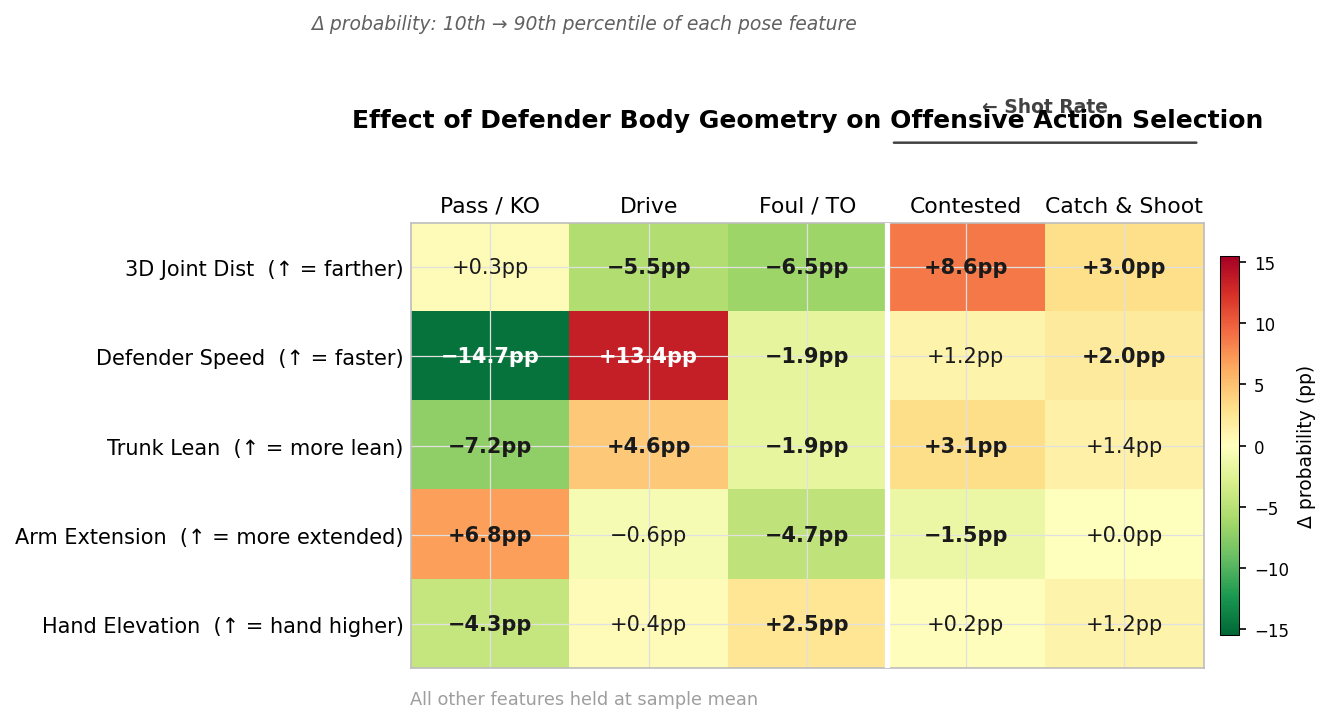

Saved → ../data/outputs/figures/pose_feature_delta_heatmap.png


In [11]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.patches as mpatches
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ── Constants ─────────────────────────────────────────────────────────────────
F2D_CTX = ['n_open_3pt_threats', 'min_kickout_defender_gap_ft',
            'release_shot_clock', 'game_clock_seconds']
POSE    = ['min_def_joint_dist_ft', 'lateral_velocity_ft_s', 'trunk_lean_deg',
           'arm_extension_ratio', 'def_hand_elev_above_ball_in']
F3D     = F2D_CTX + POSE

ROW_LABELS = [
    '3D Joint Dist  (↑ = farther)',
    'Defender Speed  (↑ = faster)',
    'Trunk Lean  (↑ = more lean)',
    'Arm Extension  (↑ = more extended)',
    'Hand Elevation  (↑ = hand higher)',
]
COL_ORDER  = ['pass_kickout', 'drive', 'foul_turnover', 'contested_shot', 'catch_and_shoot']
COL_LABELS = ['Pass / KO', 'Drive', 'Foul / TO', 'Contested', 'Catch & Shoot']

# ── 1. Load & fit ─────────────────────────────────────────────────────────────
def _load(path):
    df = pd.read_csv(path)
    for c in F3D:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna(subset=['action']).reset_index(drop=True)
    for c in F3D:
        df[c] = df[c].fillna(df[c].mean())
    return df

combined  = _load('../data/intermediate/touch_events_combined.csv')
pop_means = combined[F3D].mean().values
sc_full   = StandardScaler().fit(combined[F3D])
m_full    = LogisticRegression(solver='lbfgs', C=1.0, max_iter=800).fit(
                sc_full.transform(combined[F3D]), combined['action'].values)
classes   = list(m_full.classes_)

# ── 2. Compute 5×5 delta matrix (P90 − P10) ───────────────────────────────────
n_rows, n_cols = len(POSE), len(COL_ORDER)
delta_mat = np.zeros((n_rows, n_cols))

for ri, feat in enumerate(POSE):
    fi       = F3D.index(feat)
    p10, p90 = np.percentile(combined[feat], [10, 90])
    print(f'  {feat:<35}  p10={p10:.3f}  p90={p90:.3f}')

    row_p10 = pop_means.copy(); row_p10[fi] = p10
    row_p90 = pop_means.copy(); row_p90[fi] = p90

    prob_p10 = dict(zip(classes,
        m_full.predict_proba(sc_full.transform(row_p10.reshape(1, -1)))[0]))
    prob_p90 = dict(zip(classes,
        m_full.predict_proba(sc_full.transform(row_p90.reshape(1, -1)))[0]))

    for ci, cls in enumerate(COL_ORDER):
        delta_mat[ri, ci] = (prob_p90.get(cls, 0) - prob_p10.get(cls, 0)) * 100

print(f'\nDelta matrix (pp):\n'
      f'{pd.DataFrame(delta_mat, index=ROW_LABELS, columns=COL_LABELS).round(2)}')

# ── 3. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

vabs = np.abs(delta_mat).max() * 1.05
im   = ax.imshow(delta_mat, cmap=plt.cm.RdYlGn_r,
                 vmin=-vabs, vmax=vabs, aspect='auto')

# Cell annotations
for ri in range(n_rows):
    for ci in range(n_cols):
        val      = delta_mat[ri, ci]
        sign     = '+' if val >= 0 else '−'
        label    = f'{sign}{abs(val):.1f}pp'
        bold     = abs(val) > 1.5
        norm_val = (val + vabs) / (2 * vabs)       # 0→1 for colormap
        txt_col  = 'white' if abs(norm_val - 0.5) > 0.28 else '#1a1a1a'
        ax.text(ci, ri, label,
                ha='center', va='center', fontsize=10,
                fontweight='bold' if bold else 'normal',
                color=txt_col)

# Axis labels on top
ax.set_xticks(range(n_cols))
ax.set_xticklabels(COL_LABELS, fontsize=10.5)
ax.set_yticks(range(n_rows))
ax.set_yticklabels(ROW_LABELS, fontsize=10)
ax.tick_params(length=0)
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

# Separator line between Foul/TO and Contested
ax.axvline(2.5, color='white', linewidth=2.5, zorder=3)

# "← Shot Rate" bracket above last two columns
# Use figure-level coordinates via ax.transData + ax.transAxes
bracket_y  = 1.18    # in axes-fraction coordinates (above axes)
ax.annotate('', xy=(4.48, bracket_y), xytext=(2.52, bracket_y),
            xycoords=('data', 'axes fraction'),
            textcoords=('data', 'axes fraction'),
            arrowprops=dict(arrowstyle='-', color='#424242', lw=1.2),
            annotation_clip=False)
ax.text(3.5, bracket_y + 0.06, '← Shot Rate',
        transform=ax.get_xaxis_transform(),
        ha='center', va='bottom', fontsize=9,
        color='#424242', fontweight='bold', clip_on=False)

# Spines
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#bdbdbd')
    spine.set_linewidth(0.8)

# Colorbar
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, shrink=0.85)
cb.set_label('Δ probability (pp)', fontsize=9)
cb.ax.tick_params(labelsize=8)
cb.outline.set_linewidth(0.5)

# Title / subtitle / footnote
ax.set_title('Effect of Defender Body Geometry on Offensive Action Selection',
             fontsize=12, fontweight='bold', pad=46)
fig.text(0.44, 0.91,
         'Δ probability: 10th → 90th percentile of each pose feature',
         ha='center', va='bottom', fontsize=9, color='#616161', style='italic')
fig.text(0.44, 0.01,
         'All other features held at sample mean',
         ha='center', va='bottom', fontsize=8.5, color='#9e9e9e')

plt.tight_layout(rect=[0, 0.03, 1, 0.90])
out = FIG_DIR / 'pose_feature_delta_heatmap.png'
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out}')
